In [30]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


In [42]:
import pandas as pd
import numpy as np
df = pd.read_csv('train.csv') #https://www.kaggle.com/competitions/titanic/data?utm_source=chatgpt.com
df.head()




,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [43]:
df = df[['Pclass','Sex','Age','Fare','Survived']]
df

,Pclass,Sex,Age,Fare,Survived
0,3,male,22.0,7.2500,0
1,1,female,38.0,71.2833,1
2,3,female,26.0,7.9250,1
3,1,female,35.0,53.1000,1
4,3,male,35.0,8.0500,0
...,...,...,...,...,...
886,2,male,27.0,13.0000,0
887,1,female,19.0,30.0000,1
888,3,female,NaN,23.4500,0
889,1,male,26.0,30.0000,1


In [44]:
df.isnull().sum()

,0
Pclass,0
Sex,0
Age,177
Fare,0
Survived,0


In [45]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [46]:
df.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
Fare,0
Survived,0


In [52]:
df['Sex']= df['Sex'].map({
    'male': 0,
    'female':1
})
df['Survived'] = df['Survived'].map({
    0:'No',
    1:'Yes'
})

In [53]:
X = df.drop('Survived',axis=1) #input
y = df['Survived']   #output

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

In [73]:
X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [74]:
pred1 = model.predict(X_test)
print(pred1)

['Yes' 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes' 'No'
 'No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'No'
 'Yes' 'No' 'Yes' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'Yes'
 'Yes' 'No' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'Yes' 'Yes' 'No' 'Yes'
 'Yes' 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'No' 'Yes' 'No' 'No'
 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'Yes' 'No' 'No' 'Yes'
 'No' 'Yes' 'Yes' 'Yes' 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes'
 'Yes' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'Yes' 'No'
 'No' 'No' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No' 'No' 'Yes' 'No'
 'Yes' 'No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'No' 'No' 'No'
 'Yes' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes'
 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'Yes'
 'Yes' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No'
 'Yes' 'No' 'No' 'Yes' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'No'

In [75]:
accuracy1 = accuracy_score(pred1, y_test)
accuracy1

0.675561797752809

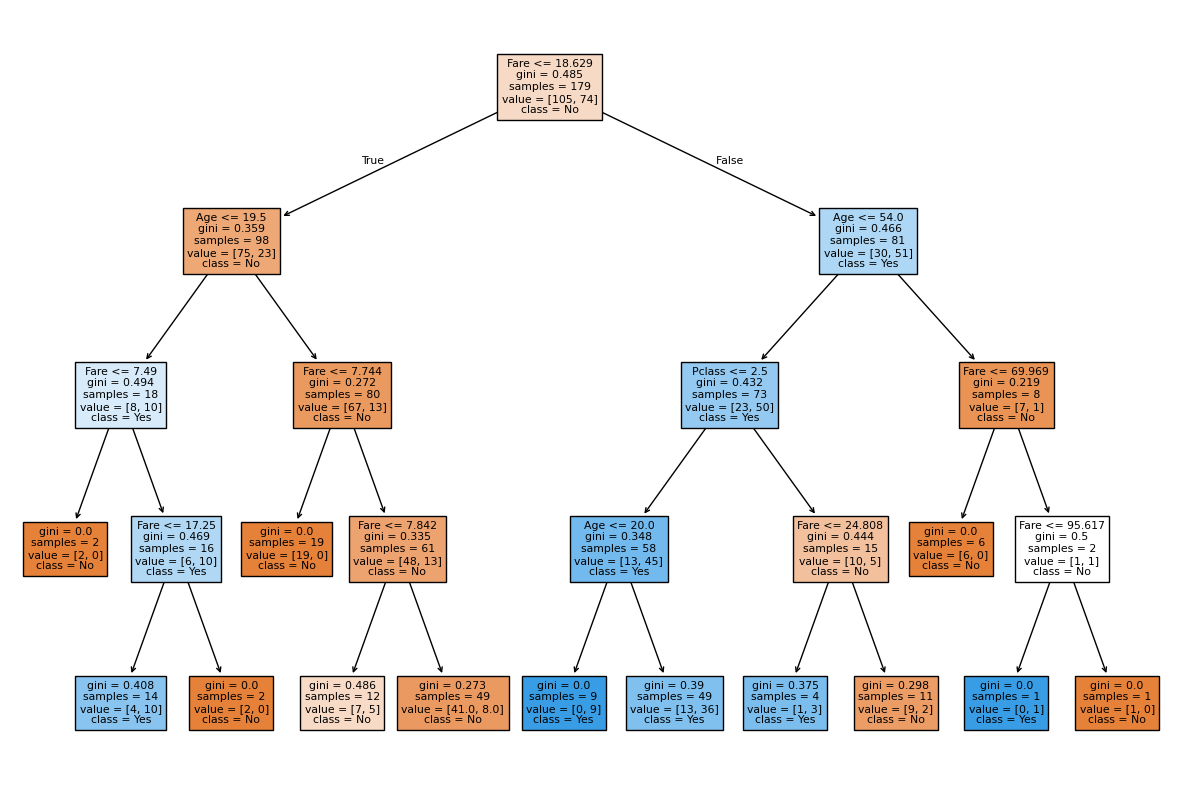

In [76]:
plt.figure(figsize=(15,10))

plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=['No', 'Yes']
)

plt.show()